# What is the best plan?

You work as an analyst for the telecommunications company Megaline The company offers customers two prepaid plans: Surf and Ultimate The commercial department wants to know which of the plans generates more revenue to adjust the advertising budget.

You will carry out a preliminary analysis of plans based on a small selection of customers You will have data on 500 Megaline customers: who they are, where they are from, what plan they use and the number of calls and messages made in 2018 Your job is to analyze customer behavior and determine which prepaid plan generates the most revenue.

## Initialization

In [ ]:
# Loading all libraries

import pandas as pd 

## Load the data

In [ ]:
# Load data files into different Data Frames

calls_df = pd.read_csv('/datasets/megaline_calls.csv')
internet_df = pd.read_csv('/datasets/megaline_internet.csv')
messages_df = pd.read_csv('/datasets/megaline_messages.csv')
plans_df = pd.read_csv('/datasets/megaline_plans.csv')
users_df = pd.read_csv('/datasets/megaline_users.csv')

## Prepare the data

## Plans

In [ ]:
# Print general information/summary about the plans Data Frame

plans_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [ ]:
# Print a sample of plan data

plans_df.head(5)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


There are no serious problems with Data Frame plans df.
Only a few improvements can be considered:
1. Convert megabytes to gigabytes to facilitate comparisons.
2. Transform usd monthly pay and usd per gb into float to facilitate data handling.

## Correct the data

In [5]:
plans_df['usd_per_gb'] = plans_df['usd_per_gb'].astype(float)
plans_df['usd_monthly_pay'] = plans_df['usd_monthly_pay'].astype(float)

In [6]:
plans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      float64
 4   usd_per_gb             2 non-null      float64
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(4), int64(3), object(1)
memory usage: 256.0+ bytes


## Enrich data

In [7]:
plans_df['gb_per_month_included'] = plans_df['mb_per_month_included'] / 1024.0

In [8]:
plans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      float64
 4   usd_per_gb             2 non-null      float64
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
 8   gb_per_month_included  2 non-null      float64
dtypes: float64(5), int64(3), object(1)
memory usage: 272.0+ bytes


## Users

In [ ]:
# Print general information/summary about users Data Frame

users_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [ ]:
# Print a sample of user data
users_df.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


The user table contains 500 records and 8 columns, with information such as name, age, city, plan and registration and cancellation dates. It is noted that the reg date and churn date columns are in text format (object), which prevents temporal analysis and needs to be corrected by converting to the datetime type. The churn date column has many missing values (only 34 filled in), which seems to indicate active customers, but this assumption must be confirmed. The other data types are adequate, but it would be useful to include an additional column such as year month to facilitate monthly groupings. Therefore, before further analysis, it is necessary to treat data types and deal with missing values appropriately.

### Correct the data

In [11]:
users_df['reg_date'] = pd.to_datetime(users_df['reg_date'])
users_df['churn_date'] = pd.to_datetime(users_df['churn_date'])

In [12]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


### Enrich data

In [13]:
users_df['year_month'] = users_df['reg_date'].dt.to_period('M')

In [14]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
 8   year_month  500 non-null    period[M]     
dtypes: datetime64[ns](2), int64(2), object(4), period[M](1)
memory usage: 35.3+ KB


## Calls

In [ ]:
# Print general information/summary about the calls Data Frame

calls_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [ ]:
# Print sample call data
calls_df.head(5)


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


The "Calls" Data Frame has 137,735 records with four columns, all without missing values, which is positive. The data types are almost adequate, but the call date column is as an object, when it should be of the datetime type to allow correct temporal analysis, such as ordering and grouping by date; this can be resolved by converting using pd to datetime(). The remaining columns (id, user id and duration) are with appropriate types. Although there is no missing data, it is still recommended to investigate possible duplicates in duration, such as zero time or excessively long calls, which may distort future analysis.

### Correct the data

In [17]:
calls_df['call_date'] = pd.to_datetime(calls_df['call_date'])

In [18]:
calls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


### Enrich data

In [19]:
calls_df['year_month'] = calls_df['call_date'].dt.to_period('M')

In [20]:
calls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id          137735 non-null  object        
 1   user_id     137735 non-null  int64         
 2   call_date   137735 non-null  datetime64[ns]
 3   duration    137735 non-null  float64       
 4   year_month  137735 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), object(1), period[M](1)
memory usage: 5.3+ MB


## Messages

In [ ]:
# Print general information/summary about the Data Frame of messages

messages_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
# Print a sample of message data

messages_df.head(5)

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


The messages table has 76,051 records and there is no missing data, which is good. However, the message date column is as text (object type), when it should be as date to facilitate analysis over time. It is also important to check that there are no repeated records or strange dates. To improve, simply convert the message date column to the date type and carry out these checks.

### Correct the data

In [ ]:
messages_df['message_date'] = pd.to_datetime(messages_df['message_date'])

In [ ]:
messages_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enrich data

In [ ]:
messages_df['year_month'] = messages_df['message_date'].dt.to_period('M')

In [ ]:
messages_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   year_month    76051 non-null  period[M]     
dtypes: datetime64[ns](1), int64(1), object(1), period[M](1)
memory usage: 2.3+ MB


## Internet

In [ ]:
# Print general information/summary about the Internet Data Frame

internet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [ ]:
# Print sample data for internet traffic

internet_df.head(5)

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


The internet table has 104,825 records, all with complete data, which is positive. However, the session date column is as text (object type), and should be converted to date to facilitate temporal analysis. It would also be good to check that there are no inconsistent values, such as mb used equal to zero, to understand if they make sense or if they need investigation. To improve, just convert session date to datetime type and carry out these checks.

### Correct the data

In [29]:
internet_df['session_date'] = pd.to_datetime(internet_df['session_date'])

In [30]:
internet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enrich data

In [31]:
internet_df['year_month'] = internet_df['session_date'].dt.to_period('M')
internet_df['gb_used'] = internet_df['mb_used'] / 1024.0

In [32]:
internet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   year_month    104825 non-null  period[M]     
 5   gb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1), period[M](1)
memory usage: 4.8+ MB


## Study the conditions of the plans

In [ ]:
# Print the plan conditions and make sure they make sense to you

plans_df

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20.0,10.0,0.03,0.03,surf,15.0
1,1000,30720,3000,70.0,7.0,0.01,0.01,ultimate,30.0


## Aggregate data by user

In [ ]:
# Calculate the number of calls made by each user per month. Save the result.

calls_per_user = calls_df.groupby(['user_id', 'year_month'])['id'].count().reset_index(name='ctn_calls')
calls_per_user.head()

,user_id,year_month,ctn_calls
0,1000,2018-12,16
1,1001,2018-08,27
2,1001,2018-09,49
3,1001,2018-10,65
4,1001,2018-11,64


In [ ]:
# Calculate the number of minutes spent by each user per month.Save the result.
duration_per_user = calls_df.groupby(['user_id', 'year_month'])['duration'].sum().reset_index(name='sum_calls')
duration_per_user.head()


,user_id,year_month,sum_calls
0,1000,2018-12,116.83
1,1001,2018-08,171.14
2,1001,2018-09,297.69
3,1001,2018-10,374.11
4,1001,2018-11,404.59


In [ ]:
# Calculate the number of messages sent by each user per month. Save the result.

msgs_per_user = messages_df.groupby(['user_id', 'year_month'])['id'].count().reset_index(name='ctn_msgs')
msgs_per_user.head()


,user_id,year_month,ctn_msgs
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36


In [ ]:
# Calculate the volume of internet traffic used by each user per month. Save the result.

internet_per_user = internet_df.groupby(['user_id', 'year_month'])['gb_used'].sum().reset_index(name='sum_gb')
internet_per_user.head()



,user_id,year_month,sum_gb
0,1000,2018-12,1.856904
1,1001,2018-08,6.756982
2,1001,2018-09,13.002754
3,1001,2018-10,21.807119
4,1001,2018-11,18.070605


In [ ]:
# Combine call, minute, message and internet data based on user id and month

merged_df = pd.merge(calls_per_user, duration_per_user, on= ['user_id', 'year_month'], how ='outer')
merged_df = pd.merge(merged_df, msgs_per_user, on= ['user_id', 'year_month'], how ='outer')
merged_df = pd.merge(merged_df, internet_per_user, on= ['user_id', 'year_month'], how ='outer')

merged_df = merged_df.fillna(0.0)

merged_df

,user_id,year_month,ctn_calls,sum_calls,ctn_msgs,sum_gb
0,1000,2018-12,16.0,116.83,11.0,1.856904
1,1001,2018-08,27.0,171.14,30.0,6.756982
2,1001,2018-09,49.0,297.69,44.0,13.002754
3,1001,2018-10,65.0,374.11,53.0,21.807119
4,1001,2018-11,64.0,404.59,36.0,18.070605
...,...,...,...,...,...,...
2288,1349,2018-12,0.0,0.00,61.0,12.734287
2289,1361,2018-05,0.0,0.00,2.0,1.484072
2290,1482,2018-10,0.0,0.00,2.0,0.000000
2291,1108,2018-12,0.0,0.00,0.0,0.227705


In [ ]:
# Add information about the plan

users_df_info = pd.merge(users_df[['user_id','plan','city']], plans_df, left_on= ['plan'], right_on= ['plan_name'])
merged_df = pd.merge(merged_df, users_df_info, on=['user_id'])

merged_df.head()

,user_id,year_month,ctn_calls,sum_calls,ctn_msgs,sum_gb,plan,city,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,1000,2018-12,16.0,116.83,11.0,1.856904,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",1000,30720,3000,70.0,7.0,0.01,0.01,ultimate,30.0
1,1001,2018-08,27.0,171.14,30.0,6.756982,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20.0,10.0,0.03,0.03,surf,15.0
2,1001,2018-09,49.0,297.69,44.0,13.002754,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20.0,10.0,0.03,0.03,surf,15.0
3,1001,2018-10,65.0,374.11,53.0,21.807119,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20.0,10.0,0.03,0.03,surf,15.0
4,1001,2018-11,64.0,404.59,36.0,18.070605,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20.0,10.0,0.03,0.03,surf,15.0


In [ ]:
# Calculate monthly revenue for each user
def calcula_receita(row):
    receita = row['usd_monthly_pay']

    sum_calls = row['sum_calls']
    minutes_included = row['minutes_included']
    usd_per_minute = row['usd_per_minute']
 
    ctn_msgs = row['ctn_msgs']
    messages_included = row['messages_included']
    usd_per_message = row['usd_per_message']

    sum_gb = row['sum_gb']
    gb_per_month_included = row['gb_per_month_included']
    usd_per_gb = row['usd_per_gb']

    if sum_calls > minutes_included:
       receita += (sum_calls - minutes_included) * usd_per_minute

    if ctn_msgs > messages_included:
       receita += (ctn_msgs - messages_included) * usd_per_message

    if sum_gb > gb_per_month_included:
       receita += (sum_gb - gb_per_month_included) * usd_per_gb

    return receita

merged_df['receita'] = merged_df.apply(calcula_receita, axis=1) 
    

In [41]:
merged_df.head()

,user_id,year_month,ctn_calls,sum_calls,ctn_msgs,sum_gb,plan,city,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included,receita
0,1000,2018-12,16.0,116.83,11.0,1.856904,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",1000,30720,3000,70.0,7.0,0.01,0.01,ultimate,30.0,70.000000
1,1001,2018-08,27.0,171.14,30.0,6.756982,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20.0,10.0,0.03,0.03,surf,15.0,20.000000
2,1001,2018-09,49.0,297.69,44.0,13.002754,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20.0,10.0,0.03,0.03,surf,15.0,20.000000
3,1001,2018-10,65.0,374.11,53.0,21.807119,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20.0,10.0,0.03,0.03,surf,15.0,88.161191
4,1001,2018-11,64.0,404.59,36.0,18.070605,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20.0,10.0,0.03,0.03,surf,15.0,50.706055


## Study user behavior

### Calls

<AxesSubplot:xlabel='year_month', ylabel='mean_duration_call'>

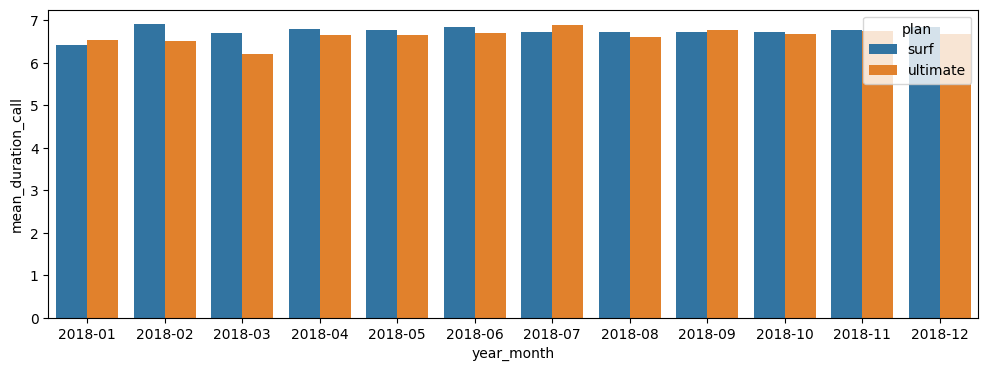

In [ ]:
# Compare the average call duration of each plan for each month. Create a bar chart to visualize the result.
import seaborn as sns
import matplotlib.pyplot as plt

aux_df = merged_df.groupby(['plan', 'year_month']).agg({'ctn_calls':'sum','sum_calls':'sum'})

aux_df['mean_duration_call'] = (aux_df['sum_calls'] / aux_df['ctn_calls'])


plt.subplots(figsize=(12,4))
sns.barplot(data=aux_df.reset_index(), x='year_month', y='mean_duration_call', hue='plan')

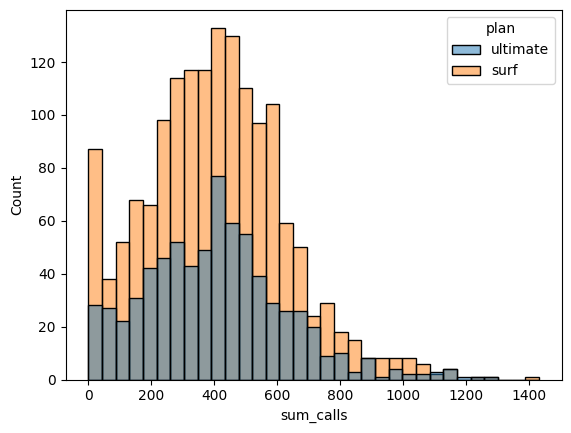

In [ ]:
# Compare the number of minutes users on each plan need each month. Build a histogram.

sns.histplot(data= merged_df, x='sum_calls', hue='plan');

In [ ]:
# Calculate the mean and variance of monthly call duration
aux_df = merged_df.groupby('year_month').agg({'sum_calls':['mean','var']})
aux_df.reset_index()

year_month   sum_calls              
                     mean           var
0     2018-01  186.388333  11978.884417
1     2018-02  324.168125  55034.331430
2     2018-03  302.306571  38297.559553
3     2018-04  327.685493  40857.825162
4     2018-05  378.862075  49052.952900
5     2018-06  388.474861  40290.973822
6     2018-07  417.719889  57598.688315
7     2018-08  390.248884  48145.862318
8     2018-09  397.839893  44405.688995
9     2018-10  411.711079  47179.463884
10    2018-11  406.066829  48599.640860
11    2018-12  442.818849  56522.142408

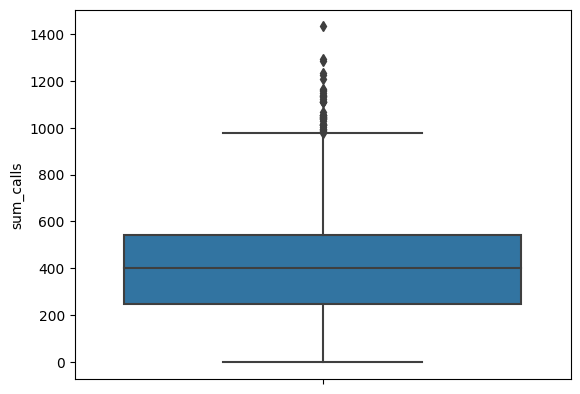

In [ ]:
# Make a box plot to visualize the distribution of monthly call duration
sns.boxplot(data=merged_df, y='sum_calls');

Users on different plans behave differently on calls. Those on one plan make longer calls, while users on the other plan make shorter, more frequent calls. Over time, call usage has increased, but there is still a lot of variation between users — some talk a lot, others a little. This shows that the plans are serving different customer profiles.

### Messages

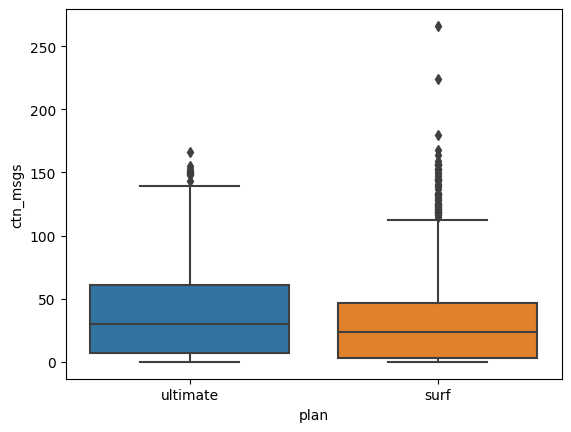

In [ ]:
# Compare the number of messages users on each plan tend to send each month
sns.boxplot(data=merged_df,x='plan', y='ctn_msgs');


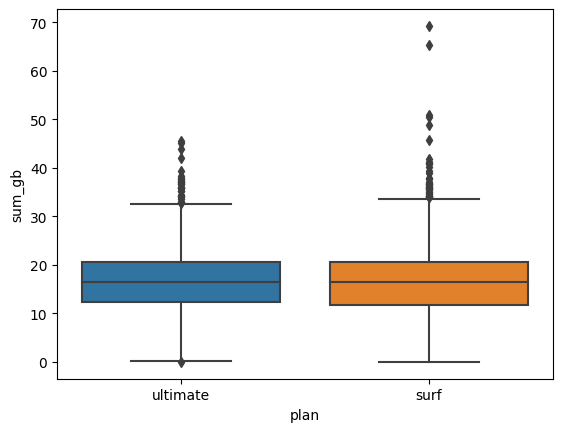

In [ ]:
# Compare the amount of internet traffic consumed by users per plan
sns.boxplot(data=merged_df,x='plan', y='sum_gb');


Surf plan users tend to send more messages compared to Ultimate plan users who send fewer messages but with more variation between them. This shows that messaging behavior is different depending on the plan.

### Internet


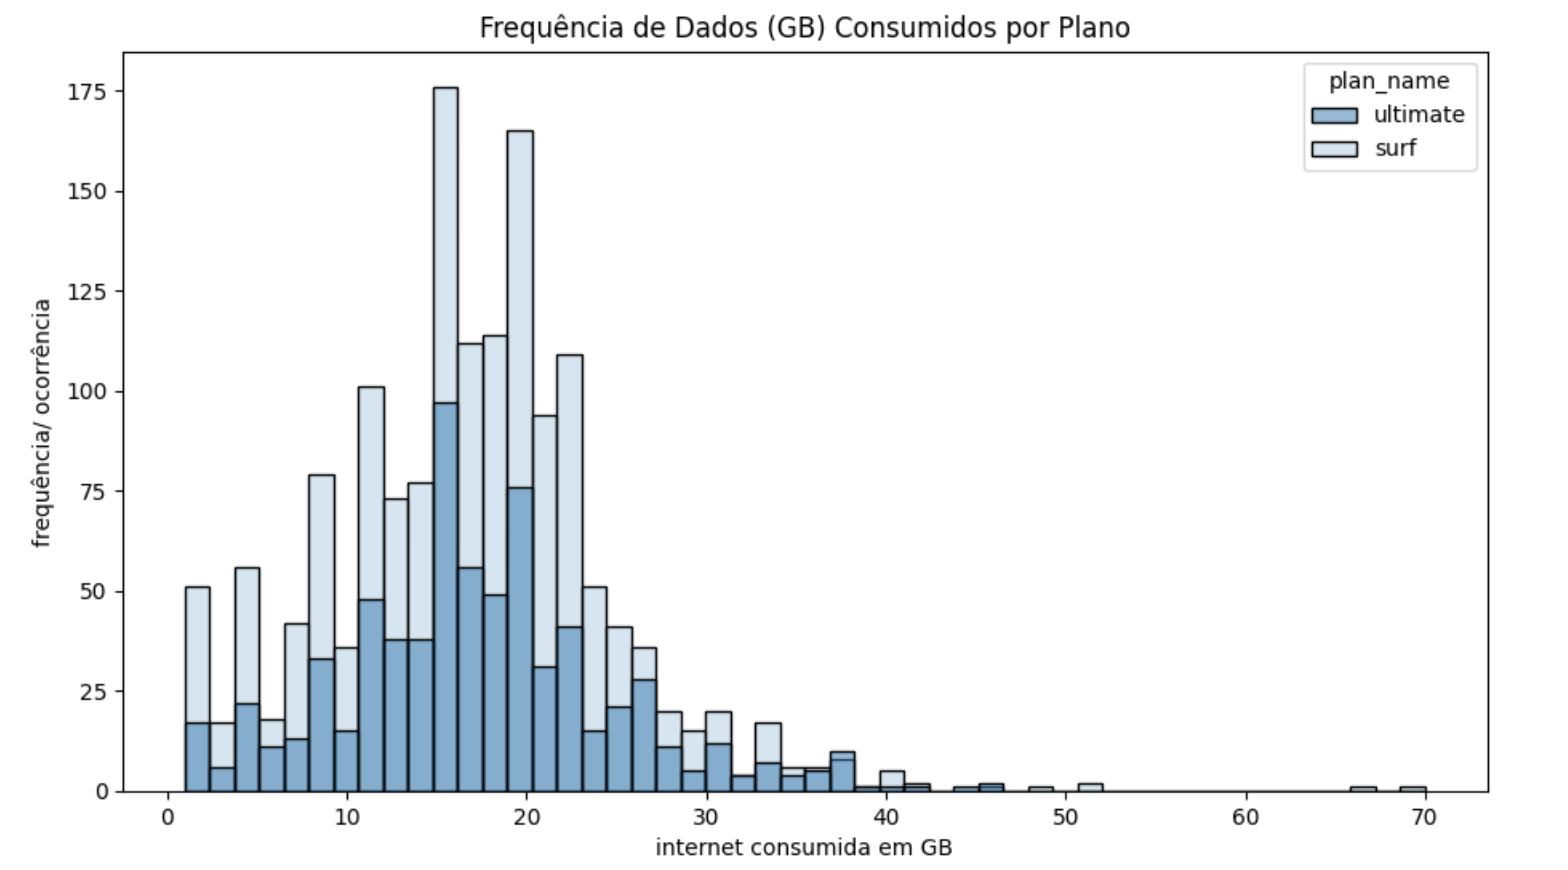
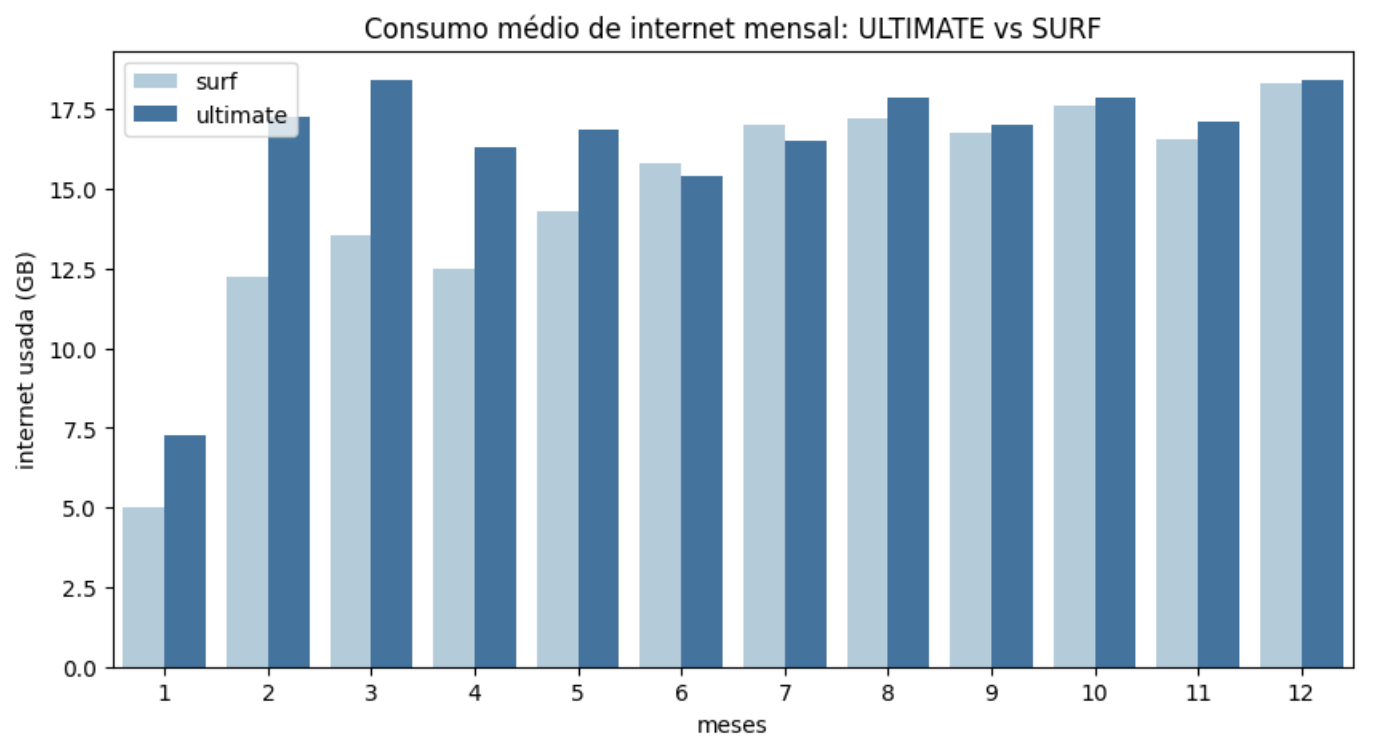



Users of the Ultimate plan tend to consume more internet traffic than those of the Surf plan. Furthermore, consumption on the Ultimate plan shows greater variation between users, indicating that some use much more internet than others. On the Surf plan, consumption is generally lower and more concentrated.
This shows that internet usage behavior is different depending on the plan contracted.

## Revenue

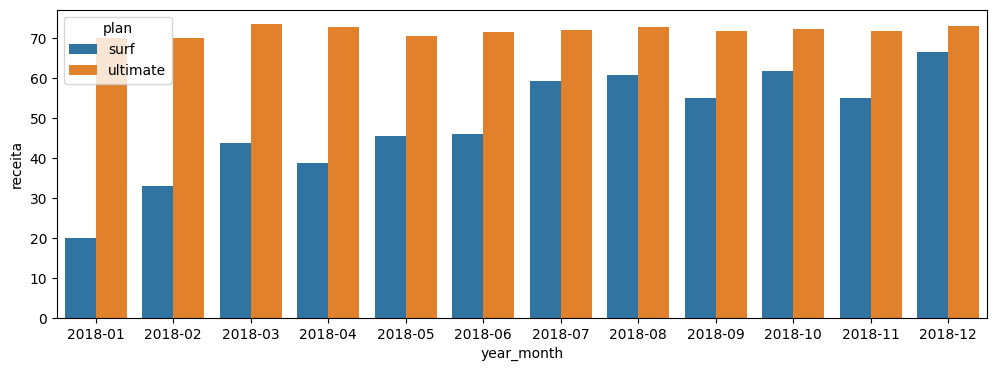

In [48]:
plt.subplots(figsize=(12,4))
sns.barplot(data=merged_df.sort_values('year_month'),x='year_month', y='receita',hue='plan', ci=None);

The Ultimate plan's revenue is consistently higher than that of the Surf plan over the months, possibly reflecting higher prices or greater consumption by users of that plan. Additionally, the Ultimate plan's revenue shows a steeper growth trend, while the Surf plan's revenue is more stable and lower.
This indicates that the Ultimate plan generates more revenue for the company, probably because it has an audience that consumes more or pays more, while the Surf plan has lower and more constant revenue.

## Test statistical hypotheses

In [ ]:
# Test hypotheses
import scipy.stats as st

# Filter revenue data by plan
surf_data = merged_df[merged_df['plan'] == 'surf']['receita']
ultimate_data = merged_df[merged_df['plan'] == 'ultimate']['receita']

# Displays the variance of each group
print("Variância do plano Surf:", surf_data.var())
print("Variância do plano Ultimate:", ultimate_data.var())

# Hypothesis test to compare revenue averages (different variances)
stats, pvalue = st.ttest_ind(surf_data, ultimate_data, equal_var=False)

# Sets the significance level
alpha = 0.05

# Decision making
if pvalue < alpha:
print("\nWe reject the null hypothesis: the plan revenue averages are significantly different ")
else:
print("\nWe cannot reject the null hypothesis: there is not enough evidence of a difference between the revenue averages ")

Variância do plano Surf: 2887.54497103938
Variância do plano Ultimate: 115.96808058212822

Rejeitamos a hipótese nula: as médias de receita dos planos são significativamente diferentes.


In [ ]:
# Test hypotheses
# Filter revenue data by plan
nynj_data = merged_df[merged_df['city'].str.contains('NY-NJ')]['receita']
other_data = merged_df[~merged_df['city'].str.contains('NY-NJ')]['receita']

# Displays the variance of each group
print("Variância de NY-NJ:", nynj_data.var())
print("Variância de other:", other_data.var())

# Hypothesis test to compare revenue averages (different variances)
stats, pvalue = st.ttest_ind(nynj_data, other_data, equal_var=False)

# Sets the significance level
alpha = 0.05

# Decision making
if pvalue < alpha:
print("\nWe reject the null hypothesis: the average revenues of users in both regions are significantly different ")
else:
print("\n We cannot reject the null hypothesis: there is no statistical evidence of a difference between the average revenue of users in NY NJ compared to users in other regions")


Variância de NY-NJ: 1777.7529232966265
Variância de other: 2116.1719888966627

Rejeitamos a hipótese nula: as médias de receita dos usuários de ambas as regiões são significativamente diferentes.


## General conclusion


Users of the Ultimate plan show call behavior with a longer average duration and greater consumption of messages and internet compared to users of the Surf plan, reflecting different usage profiles between the plans Revenue generated by the Ultimate plan is significantly higher and shows a growth trend over time, while revenue from the Surf plan remains more stable and smaller Statistical tests confirmed significant differences both between the average revenues of the plans and between the average revenues of users in the NY NJ region and the other regions. For this, we used t-tests for independent samples with different variances, adopting a significance level of 5%, ensuring the validity of the conclusions.